# Extract CPP For Retained Trials From resp_locked_erp.mat

这个 notebook 的目标是：

- 读取 `resp_locked_erp.mat`
- 读取已经和 latent 对齐好的 `retained_trials_for_latents.csv`
- 按 `subject_id + within_subject_trial_index` 提取对应 trial 的 EEG
- 计算每个 trial 的 CPP

这里默认：

- `resp_locked_erp.mat` 中每个 trial 的 shape 是 `[channel, time]`
- 通道顺序是 `CP1, CP2, CPz`
- CPP 定义为这三个通道的均值时间序列


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt


In [2]:
# paths
CURRENT_DIR = Path.cwd()
PATH_MAT = CURRENT_DIR.parent / 'script_pre_EEG' / 'Kosciessa_et_al_2021' / 'temp_data' / 'resp_locked_erp.mat'
PATH_RETAINED = CURRENT_DIR / 'data' / 'processed' / 'retained_trials_for_latents.csv'
OUTPUT_DIR = CURRENT_DIR / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PATH_MAT =', PATH_MAT)
print('PATH_RETAINED =', PATH_RETAINED)
print('OUTPUT_DIR =', OUTPUT_DIR)

PATH_MAT = /Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_pre_EEG/Kosciessa_et_al_2021/temp_data/resp_locked_erp.mat
PATH_RETAINED = /Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed/retained_trials_for_latents.csv
OUTPUT_DIR = /Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed


In [3]:
# load retained trials table
retained_trials = pd.read_csv(PATH_RETAINED)

print('retained_trials shape =', retained_trials.shape)
display(retained_trials.head())
display(retained_trials['subject_id'].value_counts().sort_index())

retained_trials shape = (7297, 23)


,original_row_index,probe_accuracy,probe_rt,probe_attribute,cue_dimensionality,probe_leftrightwin,cue_color,cue_direction,cue_size,cue_luminance,...,stim_code,resp_onset_sample,subj_id,global_behavior_row_index,subject_id,within_subject_trial_index,latent_trial_index,trial_id,metadata_original_row_index,in_latents
0,0,1.0,0.72165,1,2,2,1,1,1,1,...,8,33964.0,sub-STSWD1117,0,sub-STSWD1117,0,0.0,sub-STSWD1117_0000,0.0,1
1,1,1.0,0.82361,2,2,2,1,1,1,1,...,8,36396.0,sub-STSWD1117,1,sub-STSWD1117,1,1.0,sub-STSWD1117_0001,1.0,1
2,2,0.0,1.48840,2,2,1,1,1,1,1,...,8,41260.0,sub-STSWD1117,2,sub-STSWD1117,2,2.0,sub-STSWD1117_0002,2.0,1
3,3,0.0,0.92432,2,2,1,1,1,1,1,...,8,43692.0,sub-STSWD1117,3,sub-STSWD1117,3,3.0,sub-STSWD1117_0003,3.0,1
4,4,1.0,1.19230,1,2,1,1,1,1,1,...,8,46124.0,sub-STSWD1117,4,sub-STSWD1117,4,4.0,sub-STSWD1117_0004,4.0,1


subject_id
sub-STSWD1117    166
sub-STSWD1118    159
sub-STSWD1120    153
sub-STSWD1124    192
sub-STSWD1126    209
sub-STSWD1131    173
sub-STSWD1132    203
sub-STSWD1135    181
sub-STSWD1136    215
sub-STSWD1151    170
sub-STSWD1160    222
sub-STSWD1164    180
sub-STSWD1167    215
sub-STSWD1169    211
sub-STSWD1172    235
sub-STSWD1173    235
sub-STSWD1178    210
sub-STSWD1182    200
sub-STSWD1215    170
sub-STSWD1216    161
sub-STSWD1219    180
sub-STSWD1223    166
sub-STSWD1227    228
sub-STSWD1233    164
sub-STSWD1234    118
sub-STSWD1237    170
sub-STSWD1239    147
sub-STSWD1240    172
sub-STSWD1243    201
sub-STSWD1245    177
sub-STSWD1247    119
sub-STSWD1250    164
sub-STSWD1252    183
sub-STSWD1257    115
sub-STSWD1261    166
sub-STSWD1265    120
sub-STSWD1266    119
sub-STSWD1268    164
sub-STSWD1270    151
sub-STSWD1276    189
sub-STSWD1281    224
Name: count, dtype: int64

In [4]:
# load MAT file
mat = loadmat(PATH_MAT, squeeze_me=False)
resp_locked_erp = mat['resp_locked_erp']
subject_blocks = [np.asarray(item, dtype=np.float32) for item in resp_locked_erp.ravel()]

print('number of subject blocks =', len(subject_blocks))
print('first block shape =', subject_blocks[0].shape)
print('example single trial shape =', subject_blocks[0][0].shape)

number of subject blocks = 41
first block shape = (252, 3, 308)
example single trial shape = (3, 308)


In [5]:
# subject order used by the stage2 dataset builder
SUBJECT_IDS = [
    1117, 1118, 1120, 1124, 1126, 1131, 1132, 1135, 1136,
    1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    1182, 1215, 1216, 1219, 1223, 1227, 1233,
    1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281,
]
SUBJECT_LABELS = [f'sub-STSWD{i}' for i in SUBJECT_IDS]

subject_block_map = dict(zip(SUBJECT_LABELS, subject_blocks))

print('number of mapped subjects =', len(subject_block_map))
print('first 5 subject labels =', SUBJECT_LABELS[:5])

number of mapped subjects = 41
first 5 subject labels = ['sub-STSWD1117', 'sub-STSWD1118', 'sub-STSWD1120', 'sub-STSWD1124', 'sub-STSWD1126']


## Step 1: 逐行提取 retained trial 对应的 EEG

这里每一行 retained trial 都已经带有：

- `subject_id`
- `within_subject_trial_index`
- `latent_trial_index`

所以我们可以直接去对应被试的 block 中，取出第 `within_subject_trial_index` 个 trial。

In [6]:
trial_eeg_list = []
trial_cpp_list = []
check_rows = []

for row_idx in range(len(retained_trials)):
    row = retained_trials.iloc[row_idx]

    subject_id = row['subject_id']
    within_subject_trial_index = int(row['within_subject_trial_index'])
    latent_trial_index = int(row['latent_trial_index'])

    subject_block = subject_block_map[subject_id]

    # original shape: [trial, channel, time]
    trial_eeg = subject_block[within_subject_trial_index].astype(np.float32)

    # CPP = mean over CP1, CP2, CPz
    trial_cpp = np.nanmean(trial_eeg, axis=0).astype(np.float32)

    trial_eeg_list.append(trial_eeg)
    trial_cpp_list.append(trial_cpp)

    if row_idx < 5:
        check_rows.append({
            'row_idx': row_idx,
            'latent_trial_index': latent_trial_index,
            'subject_id': subject_id,
            'within_subject_trial_index': within_subject_trial_index,
            'trial_eeg_shape': trial_eeg.shape,
            'trial_cpp_shape': trial_cpp.shape,
        })

trial_eeg = np.stack(trial_eeg_list, axis=0)
trial_cpp = np.stack(trial_cpp_list, axis=0)

print('trial_eeg shape =', trial_eeg.shape)
print('trial_cpp shape =', trial_cpp.shape)
display(pd.DataFrame(check_rows))

trial_eeg shape = (7297, 3, 308)
trial_cpp shape = (7297, 308)


,row_idx,latent_trial_index,subject_id,within_subject_trial_index,trial_eeg_shape,trial_cpp_shape
0,0,0,sub-STSWD1117,0,"(3, 308)","(308,)"
1,1,1,sub-STSWD1117,1,"(3, 308)","(308,)"
2,2,2,sub-STSWD1117,2,"(3, 308)","(308,)"
3,3,3,sub-STSWD1117,3,"(3, 308)","(308,)"
4,4,4,sub-STSWD1117,4,"(3, 308)","(308,)"


In [7]:
# build times vector
n_timepoints = trial_cpp.shape[1]
times_ms = np.linspace(-1000.0, 200.0, n_timepoints, dtype=np.float32)

print('n_timepoints =', n_timepoints)
print('times_ms[0], times_ms[-1] =', times_ms[0], times_ms[-1])

n_timepoints = 308
times_ms[0], times_ms[-1] = -1000.0 200.0


## Step 2: 把 CPP 和 trial 标签放在一起

这里先保留一个 trial-level 的 metadata 表，后面你做回归、画图或者按被试平均都会方便。

In [8]:
cpp_trial_table = retained_trials[[
    'latent_trial_index',
    'trial_id',
    'subject_id',
    'within_subject_trial_index',
    'probe_rt',
    'probe_accuracy'
]].copy()

cpp_trial_table['cpp_mean_over_time'] = trial_cpp.mean(axis=1)
cpp_trial_table['cpp_peak_amplitude'] = trial_cpp.max(axis=1)
cpp_trial_table['cpp_min_amplitude'] = trial_cpp.min(axis=1)

display(cpp_trial_table.head())

,latent_trial_index,trial_id,subject_id,within_subject_trial_index,probe_rt,probe_accuracy,cpp_mean_over_time,cpp_peak_amplitude,cpp_min_amplitude
0,0.0,sub-STSWD1117_0000,sub-STSWD1117,0,0.72165,1.0,7.076441e-07,0.000013,-0.000005
1,1.0,sub-STSWD1117_0001,sub-STSWD1117,1,0.82361,1.0,1.015543e-06,0.000009,-0.000005
2,2.0,sub-STSWD1117_0002,sub-STSWD1117,2,1.48840,0.0,-1.544499e-06,0.000004,-0.000009
3,3.0,sub-STSWD1117_0003,sub-STSWD1117,3,0.92432,0.0,1.285380e-06,0.000009,-0.000005
4,4.0,sub-STSWD1117_0004,sub-STSWD1117,4,1.19230,1.0,-9.874783e-08,0.000009,-0.000005


## Step 3: 快速检查一下平均 CPP 波形

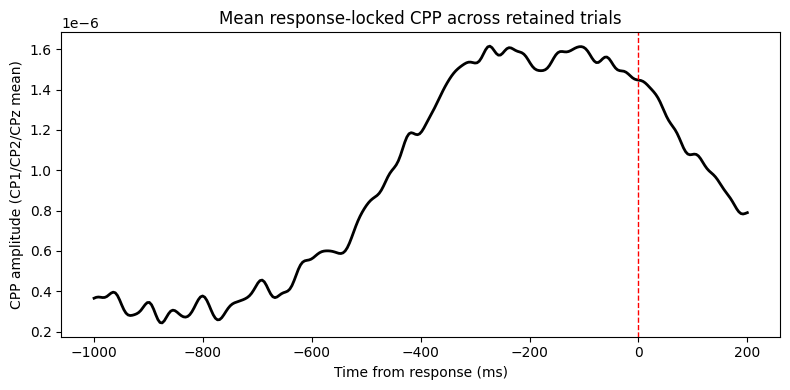

In [9]:
mean_cpp = trial_cpp.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(times_ms, mean_cpp, color='black', linewidth=2)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Time from response (ms)')
plt.ylabel('CPP amplitude (CP1/CP2/CPz mean)')
plt.title('Mean response-locked CPP across retained trials')
plt.tight_layout()
plt.show()

## Step 4: 保存结果

这里保存 3 个东西：

- `cpp_retained_trials.npy`：shape = `[7297, time]`
- `resp_locked_eeg_retained_trials.npy`：shape = `[7297, 3, time]`
- `cpp_retained_trials_metadata.csv`：每个 trial 对应的标签表
- `cpp_retained_trials_bundle.npz`：把常用东西打包到一起


In [10]:
np.save(OUTPUT_DIR / 'cpp_retained_trials.npy', trial_cpp)
np.save(OUTPUT_DIR / 'resp_locked_eeg_retained_trials.npy', trial_eeg)
cpp_trial_table.to_csv(OUTPUT_DIR / 'cpp_retained_trials_metadata.csv', index=False)

np.savez_compressed(
    OUTPUT_DIR / 'cpp_retained_trials_bundle.npz',
    cpp=trial_cpp,
    eeg=trial_eeg,
    times_ms=times_ms,
    latent_trial_index=cpp_trial_table['latent_trial_index'].to_numpy(),
    subject_id=cpp_trial_table['subject_id'].to_numpy(),
    trial_id=cpp_trial_table['trial_id'].to_numpy(),
)

print('saved files:')
print(OUTPUT_DIR / 'cpp_retained_trials.npy')
print(OUTPUT_DIR / 'resp_locked_eeg_retained_trials.npy')
print(OUTPUT_DIR / 'cpp_retained_trials_metadata.csv')
print(OUTPUT_DIR / 'cpp_retained_trials_bundle.npz')

saved files:
/Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed/cpp_retained_trials.npy
/Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed/resp_locked_eeg_retained_trials.npy
/Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed/cpp_retained_trials_metadata.csv
/Users/hyijie/Desktop/biiigProject/stage2_YuYNet/script_regression/data/processed/cpp_retained_trials_bundle.npz


## 结果解释

- `trial_cpp[i]` 就是第 `i` 个 retained trial 的 CPP 时间序列
- 这个 `i` 与 `latent_trial_index` 对齐
- 所以后面你如果要把 CPP 和 latent `Z` 或行为做回归，可以直接按 trial 顺序一一对应
